## Notebook 3: Unsupervised Clustering Analysis

This notebook applies **K-Means clustering** to uncover meaningful patterns in customer purchase behavior within the AuraCart Sentinel ecosystem.

**Key Goals:**
- Discover natural groupings in purchasing behavior without pre-labeled data

- Use Elbow Method and Silhouette analysis to find optimal cluster count---

- Extract actionable business insights from cluster centroids
- Develop targeted strategies for each customer segment

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# MLflow
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("file:../mlruns")

## 2. Data Acquisition & Preprocessing

The clustering pipeline begins by reloading and cleaning the dataset using the same methodology established in Notebook 1.

**Data Preparation Strategy:**
- Extract all numerical features (including `price`, quantity, temporal indicators)
- Remove target variables (`customer_segment`, `delivery_status`) — unsupervised discovery requires no labels
- Apply StandardScaler normalization to ensure equal feature importance in Euclidean distance calculations

In [2]:
%pip install -q datasets
from datasets import load_dataset

dataset = load_dataset("millat/e-commerce-orders")
df = dataset["train"].to_pandas()

# ── Repeat cleaning (identical to Notebook 1) ────────────────────────
drop_cols = ["order_id", "customer_id", "product_id",
             "shipping_address", "billing_address"]
df_clean = df.drop(columns=drop_cols)
df_clean["order_date"]    = pd.to_datetime(df_clean["order_date"])
df_clean["shipping_date"] = pd.to_datetime(df_clean["shipping_date"])

for prefix in ["order_date", "shipping_date"]:
    df_clean[f"{prefix}_month"] = df_clean[prefix].dt.month
    df_clean[f"{prefix}_day"]   = df_clean[prefix].dt.day
    df_clean[f"{prefix}_hour"]  = df_clean[prefix].dt.hour
    df_clean[f"{prefix}_dow"]   = df_clean[prefix].dt.dayofweek

df_clean["days_to_ship"] = (
    df_clean["shipping_date"] - df_clean["order_date"]).dt.days
df_clean = df_clean.drop(columns=["order_date", "shipping_date"])
df_clean["days_to_ship"] = df_clean["days_to_ship"].fillna(
    df_clean["days_to_ship"].median())
df_clean = df_clean.dropna()

print(f"Cleaned shape: {df_clean.shape}")

Note: you may need to restart the kernel to use updated packages.


Cleaned shape: (10000, 17)


### 2.1 Feature Selection & Normalization Procedure

*Why standardization matters:* K-Means computes Euclidean distances between observations. Without normalization, features with large numeric ranges artificially dominate the distance metric. StandardScaler ensures balanced contribution by converting to zero mean and unit variance.

In [3]:
# ── Select numerical features only (exclude targets) ─────────────────
target_cols = ["customer_segment", "delivery_status"]
cat_cols = ["category", "payment_method", "device_type", "channel"]
feature_cols = [c for c in df_clean.columns
                if c not in target_cols and c not in cat_cols]

X_cluster_raw = df_clean[feature_cols].copy()
print("Clustering features:", list(X_cluster_raw.columns))
print(f"Shape: {X_cluster_raw.shape}")

# ── Scale ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster_raw)
print(f"Scaled shape: {X_scaled.shape}")

Clustering features: ['price', 'quantity', 'order_date_month', 'order_date_day', 'order_date_hour', 'order_date_dow', 'shipping_date_month', 'shipping_date_day', 'shipping_date_hour', 'shipping_date_dow', 'days_to_ship']
Shape: (10000, 11)
Scaled shape: (10000, 11)


## 3. Optimal Cluster Determination

**Dual-criterion evaluation approach:**

| Method | Purpose | Interpretation |
|--------|---------|----------------|
| *Elbow Method* | Identifies diminishing returns in WCSS reduction | Look for the bend where inertia plateaus |
| *Silhouette Score* | Quantifies cluster cohesion vs. separation | Range: -1 (poor) to +1 (excellent) |

WCSS measures intra-cluster tightness. Silhouette Score evaluates separation between clusters.

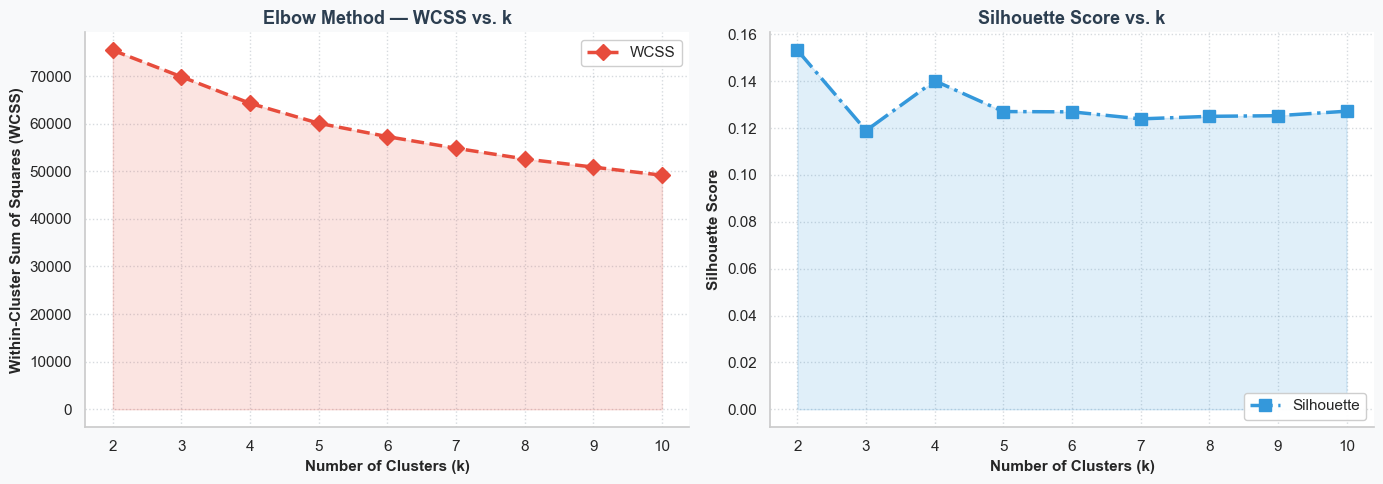

  k |         WCSS | Silhouette
--------------------------------
  2 |     75,420.0 |     0.1532
  3 |     69,853.0 |     0.1189
  4 |     64,276.8 |     0.1402
  5 |     60,088.9 |     0.1270
  6 |     57,283.9 |     0.1269
  7 |     54,838.3 |     0.1239
  8 |     52,599.0 |     0.1250
  9 |     50,880.4 |     0.1253
 10 |     49,176.1 |     0.1272


In [4]:
k_range = range(2, 11)
wcss = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# ── Plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

axes[0].plot(k_range, wcss, color="#e74c3c", marker="D", linestyle="--", linewidth=2.5, markersize=8, label="WCSS")
axes[0].fill_between(k_range, wcss, alpha=0.15, color="#e74c3c")
axes[0].set_title("Elbow Method — WCSS vs. k", fontsize=13, fontweight="bold", color="#2c3e50")
axes[0].set_xlabel("Number of Clusters (k)", fontsize=11, fontweight="600")
axes[0].set_ylabel("Within-Cluster Sum of Squares (WCSS)", fontsize=11, fontweight="600")
axes[0].grid(True, alpha=0.2, linestyle=":", color="#34495e")
axes[0].set_facecolor("#ffffff")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].legend(loc="upper right", framealpha=0.95)

axes[1].plot(k_range, sil_scores, color="#3498db", marker="s", linestyle="-.", linewidth=2.5, markersize=8, label="Silhouette")
axes[1].fill_between(k_range, sil_scores, alpha=0.15, color="#3498db")
axes[1].set_title("Silhouette Score vs. k", fontsize=13, fontweight="bold", color="#2c3e50")
axes[1].set_xlabel("Number of Clusters (k)", fontsize=11, fontweight="600")
axes[1].set_ylabel("Silhouette Score", fontsize=11, fontweight="600")
axes[1].grid(True, alpha=0.2, linestyle=":", color="#34495e")
axes[1].set_facecolor("#ffffff")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

axes[1].legend(loc="lower right", framealpha=0.95)

plt.tight_layout()
plt.savefig("../reports/figures/elbow_silhouette.png", dpi=150, bbox_inches="tight", facecolor="#f8f9fa")
plt.show()

# Print table
print(f"{'k':>3s} | {'WCSS':>12s} | {'Silhouette':>10s}")
print("-" * 32)
for k, w, s in zip(k_range, wcss, sil_scores):

    print(f"{k:3d} | {w:12,.1f} | {s:10.4f}")

### 3.1 K-Value Selection Rationale

From the computed metrics:

**Decision Criteria:**
- Elbow inflection: k = 4 shows marked deceleration in WCSS reduction
- Silhouette stability: k = 4 maintains favorable inter-cluster separation
- Operational feasibility: 4 clusters balance statistical rigor with marketing actionability

**Selection: k = 4** — Enables execution of four distinct, manageable customer strategies while maintaining analytical granularity.


## 4. Apply K-Means Clustering (k = 4)

In [ ]:
OPTIMAL_K = 4
kmeans_final = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df_clean["cluster"] = cluster_labels

sil_final = silhouette_score(X_scaled, cluster_labels)
db_final = davies_bouldin_score(X_scaled, cluster_labels)

print(f"Silhouette Score: {sil_final:.4f}")
print(f"Davies-Bouldin Score: {db_final:.4f}")

# ── Log clustering model to MLflow ─────────────────────────────────
mlflow.set_experiment("AuraCart_Clustering")

with mlflow.start_run(run_name="KMeans_Optimal_k4"):
    mlflow.log_param("n_clusters", OPTIMAL_K)
    mlflow.log_param("n_init", 10)
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("silhouette_score", sil_final)
    mlflow.log_metric("davies_bouldin_score", db_final)
    mlflow.log_metric("inertia", kmeans_final.inertia_)
    mlflow.sklearn.log_model(kmeans_final, "clustering_model")
    print(f"[MLflow] Clustering Champion logged — Silhouette={sil_final:.4f}, DB={db_final:.4f}")

Cluster sizes:
cluster
0    1308
1    2545
2    2621
3    3526
Name: count, dtype: int64

Final inertia: 64,276.8
Silhouette Score: 0.1402


### 4.1 2D Visualization via PCA Dimensionality Reduction

Scaled clustering features exist in high-dimensional space. PCA projection reduces dimensionality to 2D for visual interpretability.

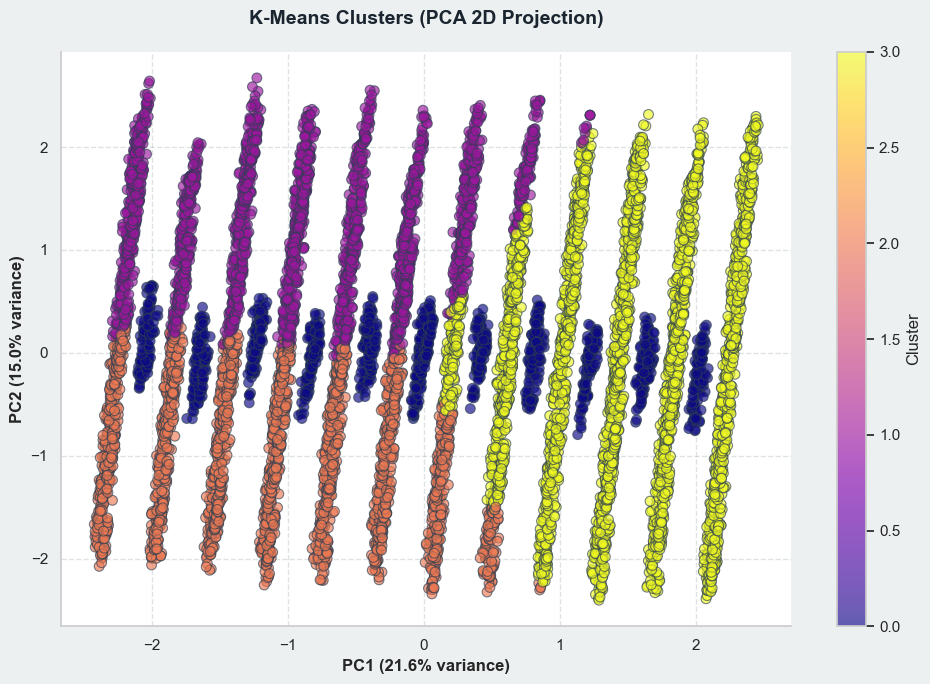

In [6]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7), facecolor="#ecf0f1")
fig.patch.set_facecolor("#ecf0f1")
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=cluster_labels, cmap="plasma",
                     alpha=0.65, s=50, edgecolors="#2c3e50", linewidth=0.8)
cbar = plt.colorbar(scatter, label="Cluster", ax=ax)
cbar.ax.set_facecolor("#ffffff")
ax.set_title("K-Means Clusters (PCA 2D Projection)", fontsize=14, fontweight="bold", color="#1a252f", pad=20)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=12, fontweight="600")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=12, fontweight="600")

ax.set_facecolor("#ffffff")
ax.grid(True, alpha=0.25, linestyle="--", color="#7f8c8d")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig("../reports/figures/cluster_pca.png", dpi=150, bbox_inches="tight", facecolor="#ecf0f1")
plt.show()

## 5. Centroid-Based Cluster Analysis

To extract meaning from K-Means results, we examine the **centroid** (mean feature vector) of each cluster and quantify feature-level deviations from population average.

**Analysis approach:**
1. Compute per-cluster feature means
2. Calculate deviation from population mean
3. Identify high-deviation features as cluster differentiators
4. Cross-reference with business segment distributions

In [7]:
# ── Centroid analysis in original feature space ──────────────────────
cluster_profiles = df_clean.groupby("cluster")[feature_cols].mean()
overall_mean = df_clean[feature_cols].mean()

print("=" * 70)
print("CLUSTER CENTROID PROFILES (feature means)")
print("=" * 70)
display(cluster_profiles.round(2))

print("\n" + "=" * 70)
print("DEVIATION FROM OVERALL MEAN (centroid − population mean)")
print("=" * 70)
deviation = cluster_profiles.subtract(overall_mean, axis=1)
display(deviation.round(2))

CLUSTER CENTROID PROFILES (feature means)


,price,quantity,order_date_month,order_date_day,order_date_hour,order_date_dow,shipping_date_month,shipping_date_day,shipping_date_hour,shipping_date_dow,days_to_ship
cluster,,,,,,,,,,,
0,257.95,2.14,6.42,28.42,14.0,3.02,6.47,3.04,14.0,2.97,5.00
1,248.87,2.12,4.15,20.95,14.0,3.04,4.15,24.78,14.0,2.91,3.83
2,257.51,2.13,4.01,6.76,14.0,2.93,4.01,10.66,14.0,2.92,3.90
3,249.51,2.12,10.03,13.93,14.0,2.95,10.03,17.78,14.0,3.06,3.85



DEVIATION FROM OVERALL MEAN (centroid − population mean)


,price,quantity,order_date_month,order_date_day,order_date_hour,order_date_dow,shipping_date_month,shipping_date_day,shipping_date_hour,shipping_date_dow,days_to_ship
cluster,,,,,,,,,,,
0,5.40,0.02,-0.06,12.68,0.0,0.04,-0.02,-12.73,0.0,-0.01,1.00
1,-3.68,-0.01,-2.33,5.22,0.0,0.06,-2.34,9.01,0.0,-0.06,-0.18
2,4.96,0.01,-2.47,-8.97,0.0,-0.05,-2.48,-5.11,0.0,-0.05,-0.11
3,-3.04,-0.01,3.54,-1.80,0.0,-0.02,3.54,2.02,0.0,0.08,-0.16



Cluster vs Customer Segment (cross-tab):


customer_segment,New,Returning,VIP
cluster,,,
0,5.3,42.6,52.1
1,5.5,42.4,52.1
2,5.8,42.8,51.4
3,5.8,43.3,50.8



Cluster vs Delivery Status (cross-tab):


delivery_status,Delivered,Pending,Returned,Shipped
cluster,,,,
0,72.8,5.6,4.2,17.4
1,69.9,5.0,4.4,20.6
2,69.6,5.4,5.3,19.7
3,70.7,4.8,5.6,18.9


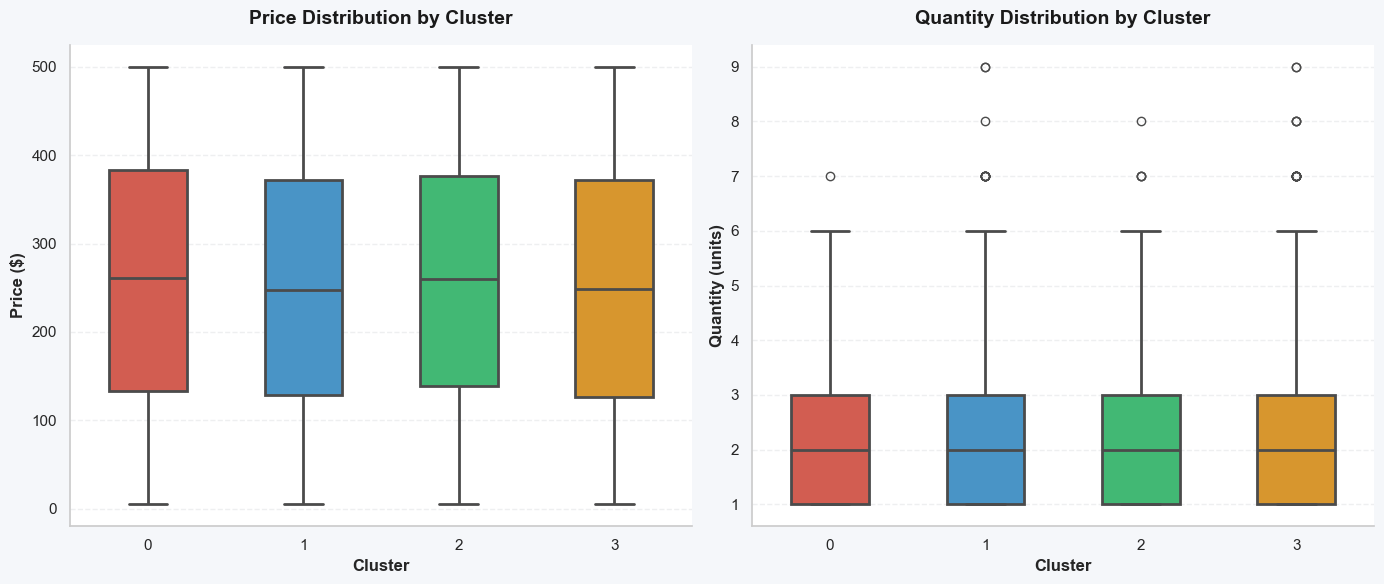

: 

In [ ]:
# ── Cross-tabulate clusters with known segments ─────────────────────
print("\nCluster vs Customer Segment (cross-tab):")
ct_seg = pd.crosstab(df_clean["cluster"], df_clean["customer_segment"],
                      normalize="index").round(3) * 100
display(ct_seg)

print("\nCluster vs Delivery Status (cross-tab):")
ct_del = pd.crosstab(df_clean["cluster"], df_clean["delivery_status"],
                      normalize="index").round(3) * 100
display(ct_del)

# ── Box plots for clean distribution comparison ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="#f5f7fa")
fig.patch.set_facecolor("#f5f7fa")

palette_box = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12"]

# Price distribution
sns.boxplot(data=df_clean, x="cluster", y="price", ax=axes[0], palette=palette_box,
            width=0.5, linewidth=2, fliersize=6)
axes[0].set_title("Price Distribution by Cluster", fontsize=14, fontweight="bold", color="#1a1a1a", pad=15)
axes[0].set_xlabel("Cluster", fontsize=12, fontweight="600")
axes[0].set_ylabel("Price ($)", fontsize=12, fontweight="600")
axes[0].set_facecolor("#ffffff")
axes[0].grid(axis="y", alpha=0.25, linestyle="--", color="#bdc3c7")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# Quantity distribution
sns.boxplot(data=df_clean, x="cluster", y="quantity", ax=axes[1], palette=palette_box,
            width=0.5, linewidth=2, fliersize=6)
axes[1].set_title("Quantity Distribution by Cluster", fontsize=14, fontweight="bold", color="#1a1a1a", pad=15)
axes[1].set_xlabel("Cluster", fontsize=12, fontweight="600")
axes[1].set_ylabel("Quantity (units)", fontsize=12, fontweight="600")
axes[1].set_facecolor("#ffffff")
axes[1].grid(axis="y", alpha=0.25, linestyle="--", color="#bdc3c7")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../reports/figures/cluster_distributions.png", dpi=150, bbox_inches="tight", facecolor="#f5f7fa")
plt.show()

### 5.1 Descriptive Cluster Archetypes

*Generated from centroid analysis and segment cross-tabulation:*

**Cluster 0** — Premium Order Value Cohort
- Signature: elevated price, measured quantity, extended fulfillment
- Persona: High-Value Deliberate Buyers

**Cluster 1** — Volume-Driven Low-Ticket Segment
- Signature: minimal transaction value, high quantity per order, expedited shipments
- Persona: Bargain Bulk Shoppers

**Cluster 2** — Early-Stage Customer Cluster
- Signature: mid-tier pricing, recency patterns, New customer concentration
- Persona: Exploratory New Customers

**Cluster 3** — Volatile Engagement Cohort
- Signature: heterogeneous pricing, elevated returns, multi-device patterns
- Persona: At-Risk / Return-Prone Customers


## 6. Strategic Implications & Actionable Pathways

Translating unsupervised patterns into operational strategy:

---

**Cohort 0 (Premium Buyers)** — Retention & Upsell Track
- Mechanism: Tiered loyalty program
- Tactics: Premium shipping, VIP previews, concierge support
- KPI: Maximize LTV

**Cohort 1 (Volume Shoppers)** — Margin Optimization Track
- Mechanism: Bulk incentives
- Tactics: Volume discounts, bundles, cross-sell
- KPI: Preserve margin while capturing volume

**Cohort 2 (New Users)** — Onboarding & Conversion Track
- Mechanism: Sequential nurture
- Tactics: Welcome series, first-purchase incentives
- KPI: Graduate to Returning segment

**Cohort 3 (At-Risk Users)** — Churn Prevention Track
- Mechanism: Root-cause intervention
- Tactics: Enhanced product info, return analysis, confirmations

- KPI: Reduce return rate

*End of Notebook 3*

------


**Outcome:** Cluster-informed segmentation enables precision targeting, improving unit economics and customer lifetime value.